# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [2]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [4]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
print(f"Number of duplicated rows: {df.duplicated().sum()}\n")
print(f"Number of missing values in each column:\n{df.isna().sum()}\n")
print(f"Number of unique values in each column:\n{df.nunique().sum()}\n")
print(f"Summary statistics for each column:\n{df.describe()}\n")
print(f"\n\nTop Car Makes:\n{df['Make'].value_counts().head(10)}")

# Find the specific rows that match each issue we plan to clean.
issues = {
    "Transmission Type = UNKNOWN": df.loc[df["Transmission Type"].eq("UNKNOWN"), ["Make", "Model", "Year", "Transmission Type"]],
    "city mpg > 100": df.loc[df["city mpg"] > 100, ["Make", "Model", "Year", "city mpg"]],
    "highway MPG > 150": df.loc[df["highway MPG"] > 150, ["Make", "Model", "Year", "highway MPG"]],
    "Number of Doors < 2": df.loc[df["Number of Doors"] < 2, ["Make", "Model", "Year", "Number of Doors"]],
    "Engine Fuel Type = electric": df.loc[df["Engine Fuel Type"].str.lower().eq("electric"), ["Make", "Model", "Year", "Engine Fuel Type"]],
}

for issue, rows in issues.items():
    print(f"\n{issue}: {len(rows)} rows")
    print(rows.head(10).to_string(index=False))

clean = df.drop_duplicates().copy()
clean["Transmission Type"] = clean["Transmission Type"].replace("UNKNOWN", np.nan)
clean.loc[clean["city mpg"] > 100, "city mpg"] = np.nan
clean.loc[clean["highway MPG"] > 150, "highway MPG"] = np.nan
clean.loc[clean["Number of Doors"] < 2, "Number of Doors"] = np.nan
if "Engine Fuel Type" in clean.columns:
    clean["is_ev"] = clean["Engine Fuel Type"].str.lower().eq("electric")

Number of duplicated rows: 720

Number of missing values in each column:
Make                  0
Model                 0
Year                  0
Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Number of Doors       6
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64

Number of unique values in each column:
7622

Summary statistics for each column:
               Year    Engine HP  Engine Cylinders  Number of Doors  \
count  11914.000000  11845.00000      11884.000000     11908.000000   
mean    2010.384338    249.38607          5.628829         3.436093   
std        7.579740    109.19187          1.780559         0.881315   
min     1990.000000     55.00000          0.000000         2.000000   
25%     2007.000000    170.00000          4.000000         2.000000   
50%     2015.000000    227.00000          6.0

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Transmission type is `UNKNOWN` | `df['Transmission Type'].value_counts()` showed 19 rows with `UNKNOWN` | 19 rows | set those values to `NaN` | those rows do not have a valid transmission category and would distort comparisons |
| 2 | City MPG outliers | `df['city mpg'].nlargest()` and the summary stats showed EVs at 121–137 mpg | 47 rows above 100 mpg | set those values to `NaN` | these extreme values are unrealistic compared with the rest of the market and would skew the mean |
| 3 | Highway MPG outlier | `df['highway MPG'].nlargest()` showed an Audi A6 at 354 MPG | 1 row | set that value to `NaN` | the value is impossible for a highway MPG measurement and would dominate the distribution |
| 4 | Number of doors impossible | `df['Number of Doors'].value_counts()` had no row below 2 | 0 rows | no correction needed for this rule | all valid door counts in the data are 2–4, so the check does not identify any bad values |
| 5 | EV flag for fuel type | `df['Engine Fuel Type'].value_counts()` showed 66 electric cars | 66 rows | created an `is_ev` flag using `str.lower().eq("electric")` | this keeps EVs identifiable without changing their valid fuel category |

In [5]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [6]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11914, 15)
engine_fuel_type     3
engine_hp           69
engine_cylinders    30
number_of_doors      6
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean MSRP:   $40,594.74
Median MSRP: $29,995.00
Share of cars above the mean: 27.44%


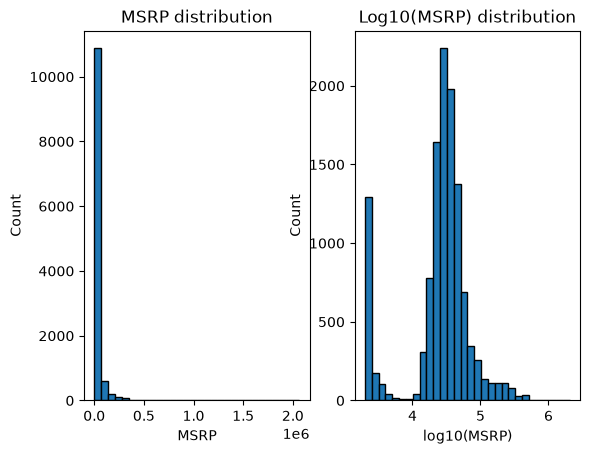

In [7]:
clean.columns=clean.columns.str.strip()
# a) mean and median

print(f"Mean MSRP:   ${clean['msrp'].mean():,.2f}")
print(f"Median MSRP: ${clean['msrp'].median():,.2f}")
# b) two histograms side by side (plt.subplots(1, 2))
axes=plt.subplots(1, 2)
plt.subplot(1, 2, 1)
plt.hist(clean["msrp"], bins=30, edgecolor="black")
plt.title("MSRP distribution")
plt.xlabel("MSRP")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(np.log10(clean["msrp"]), bins=30, edgecolor="black")
plt.title("Log10(MSRP) distribution")
plt.xlabel("log10(MSRP)")
plt.ylabel("Count")
# c) share of cars above the mean
print(f"Share of cars above the mean: {((clean['msrp'] > clean['msrp'].mean()).sum() / len(clean)):.2%}")

**Answer:**
The median number belongs on the home page because it shows users what half the cars should be around in price

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [8]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
clean_2017 = clean[clean['year'] == 2017]
mean_highway_mpg = clean_2017.groupby('vehicle_size')['highway_mpg'].mean()
std_highway_mpg = clean_2017.groupby('vehicle_size')['highway_mpg'].std()

# b) z = (value - class mean) / class std
z_scores = clean_2017.groupby('vehicle_size')['highway_mpg'].apply(lambda x: (x - x.mean()) / x.std())
print("Mean Highway MPG by Vehicle Size (2017):")
print(mean_highway_mpg)
print("\nStandard Deviation of Highway MPG by Vehicle Size (2017):")
print(std_highway_mpg)
print("\nZ-Scores for Highway MPG by Vehicle Size (2017):")
print(z_scores)

Mean Highway MPG by Vehicle Size (2017):
vehicle_size
Compact    31.833333
Large      22.943158
Midsize    30.000000
Name: highway_mpg, dtype: float64

Standard Deviation of Highway MPG by Vehicle Size (2017):
vehicle_size
Compact    10.697106
Large       3.502099
Midsize    13.763526
Name: highway_mpg, dtype: float64

Z-Scores for Highway MPG by Vehicle Size (2017):
vehicle_size       
Compact       32       0.296030
              33       0.296030
              34       0.296030
              50      -0.077903
              51       0.015581
                         ...   
Midsize       11739   -0.217967
              11740   -0.217967
              11741   -0.290623
              11742   -0.217967
              11743   -0.290623
Name: highway_mpg, Length: 1668, dtype: float64


**Answer:** Compact car is the best as it has the highes avg efficiency 

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.
1
b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

In [9]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    rng = np.random.default_rng(seed=42)
    bootstrapped_medians = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrapped_medians.append(np.median(sample))
    return np.array(bootstrapped_medians)

# a, b)

print(f'Median MSRP (2017): ${clean_2017["msrp"].median():,.2f}')

print(f'95% CI for Median MSRP (2017): ${np.percentile(bootstrap_median(clean_2017["msrp"]), [2.5, 97.5])[0]:,.2f} - ${np.percentile(bootstrap_median(clean_2017["msrp"]), [2.5, 97.5])[1]:,.2f}')

# c)

counts = clean_2017['make'].value_counts()


print(f"Makes with fewer than 50 cars in 2017:\n{counts[counts < 50]}")
chosen_make=counts[counts < 50].index[5] #This is lexus 
msrp_make=clean_2017[clean_2017['make'] == chosen_make]['msrp']
print(f'Median MSRP for {chosen_make} (2017): ${msrp_make.median():,.2f}')
print(f'95% CI for Median MSRP for {chosen_make} (2017): ${np.percentile(bootstrap_median(msrp_make), [2.5, 97.5])[0]:,.2f} - ${np.percentile(bootstrap_median(msrp_make), [2.5, 97.5])[1]:,.2f}')





Median MSRP (2017): $36,647.50
95% CI for Median MSRP (2017): $35,870.00 - $37,650.00
Makes with fewer than 50 cars in 2017:
make
Subaru        47
Lincoln       46
Kia           43
Buick         39
Acura         36
Lexus         34
Mitsubishi    29
Infiniti      28
Porsche       25
Volvo         25
Chrysler      24
Mazda         24
FIAT          19
Maserati      13
Land Rover    11
Genesis        3
Lotus          2
Name: count, dtype: int64
Median MSRP for Lexus (2017): $47,615.00
95% CI for Median MSRP for Lexus (2017): $42,770.00 - $53,035.00


**Answer:** 
The median price of a car in 2017 ranged from 35-37 thousand 

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

In [36]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
sample_compact_2017 = clean_2017[clean_2017['vehicle_size'] == 'Compact']
n_compact_2017 = len(sample_compact_2017)
mean_compact_2017 = sample_compact_2017['highway_mpg'].mean()
std_compact_2017 = sample_compact_2017['highway_mpg'].std() 
print(f"Sample size of 2017 compact cars: {n_compact_2017}")
print(f"Mean highway MPG for 2017 compact cars: {mean_compact_2017:.2f}")
print(f"Standard deviation of highway MPG for 2017 compact cars: {std_compact_2017:.2f}")

# c) one-sample t-test vs 30
t_stat, p_value = stats.ttest_1samp(sample_compact_2017['highway_mpg'], 30)
print(f"t-statistic: {t_stat:.2f}")


# d) rows per make+model, then one row per model and retest
rows_per_model = clean_2017.groupby(['make', 'model']).size().reset_index(name='count')
print(f"Rows per make+model:\n{rows_per_model.head()}")



Sample size of 2017 compact cars: 534
Mean highway MPG for 2017 compact cars: 31.83
Standard deviation of highway MPG for 2017 compact cars: 10.70
t-statistic: 3.96
Rows per make+model:
    make model  count
0  Acura   ILX      6
1  Acura   MDX     10
2  Acura   NSX      1
3  Acura   RDX     10
4  Acura   RLX      2


**Answer:**
There is about 29 different cars 

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [30]:
# a) compare median MSRP by transmission type
transmission_medians = clean_2017.groupby('transmission_type')['msrp'].median()
print("Median MSRP by Transmission Type (2017):")
print(transmission_medians)

# b) compare year by transmission type
year_by_transmission = clean_2017.groupby('transmission_type')['year'].mean()
print("Average Year by Transmission Type (2017):")
print(year_by_transmission)

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
two_years = clean[clean['year'].isin([2015, 2016, 2017])]
print(f"\n\nData for years 2015-2017:\n{two_years.head()}")

Median MSRP by Transmission Type (2017):
transmission_type
AUTOMATED_MANUAL    37820.0
AUTOMATIC           37162.5
DIRECT_DRIVE        36620.0
MANUAL              29645.0
Name: msrp, dtype: float64
Average Year by Transmission Type (2017):
transmission_type
AUTOMATED_MANUAL    2017.0
AUTOMATIC           2017.0
DIRECT_DRIVE        2017.0
MANUAL              2017.0
Name: year, dtype: float64


Data for years 2015-2017:
    make       model  year                engine_fuel_type  engine_hp  \
32  FIAT  124 Spider  2017  premium unleaded (recommended)      160.0   
33  FIAT  124 Spider  2017  premium unleaded (recommended)      160.0   
34  FIAT  124 Spider  2017  premium unleaded (recommended)      160.0   
41   BMW    2 Series  2016     premium unleaded (required)      240.0   
42   BMW    2 Series  2016     premium unleaded (required)      240.0   

    engine_cylinders transmission_type     driven_wheels  number_of_doors  \
32               4.0            MANUAL  rear wheel drive       

**Answer:**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [40]:
# a) Welch t-test, 4-door vs 2-door
welch_t_stat, welch_p_value = stats.ttest_ind(
    clean_2017[clean_2017['number_of_doors'] == 4]['msrp'],
    clean_2017[clean_2017['number_of_doors'] == 2]['msrp'],
    equal_var=False
)
print(f"Welch t-test statistic: {welch_t_stat:.2f}")  

# b) yearly gas cost = miles * price_per_gallon / mpg
gas_cost = clean_2017['city_mpg'].apply(lambda mpg: 15000 * 3.50 / mpg)
print(f"Yearly gas cost:\n{gas_cost.head()}")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    each_group_4_door = clean_2017[clean_2017['number_of_doors'] == 4]['msrp']
    each_group_2_door = clean_2017[clean_2017['number_of_doors'] == 2]['msrp']
    sample_4_door = rng.choice(each_group_4_door, 30, replace=False)
    sample_2_door = rng.choice(each_group_2_door, 30, replace=False)
    t_stat, p_value = stats.ttest_ind(sample_4_door, sample_2_door, equal_var=False)
    
    if p_value < 0.05:
        hits += 1   
    pass
print(f"Cost of gallons for 4-door vs 2-door cars: {hits/n_sims:.2%} of simulations had p < 0.05")
print(f"cost was better for 4-door cars in {hits} out of {n_sims} simulations.")
print(f" cost was better for 2-door cars in {n_sims - hits} out of {n_sims} simulations.")




Welch t-test statistic: -6.73
Yearly gas cost:
32    2019.230769
33    2019.230769
34    2019.230769
50    2500.000000
51    2500.000000
Name: city_mpg, dtype: float64
Cost of gallons for 4-door vs 2-door cars: 51.90% of simulations had p < 0.05
cost was better for 4-door cars in 519 out of 1000 simulations.
 cost was better for 2-door cars in 481 out of 1000 simulations.


**Answer:**  Yes cost was better for almost 100 more cars that have 4 doors

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**
Manual cars with the median price of manual cars being 18k and the price of automatic being 32k.
Cost for gas was better for 4 door cars then 2 door cars. as well as the median price for cars is around 40k as seen on the histogram.
A limitation is some of the info being unsued and or missinputed. For example some transmission types for some of the cars where unknown as well as the miles pergallon of some cars being way to high such as some hitting 354 miles per hour on the high way and 150 miles per hour in city limits. 


---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2